In [16]:
# LIBRERÍA: PANDAS Y NUMPY
# limpieza y análisis de datos financieros
import pandas as pd
import numpy as np

# Cargamos el CSV con los datos financieros
ruta_csv = r"C:\Entregable\datos_financieros.csv"
df = pd.read_csv(ruta_csv)

# Convertimos la columna Fecha a formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'])

print('---INFORMACIÓN GENERAL DEL DATASET---')
print(df.info())

print('\n---PRIMEROS REGISTROS---')
print(df.head())

print('\n---ESTADÍSTICAS DESCRIPTIVAS---')
print(df.describe())

---INFORMACIÓN GENERAL DEL DATASET---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Fecha     400 non-null    datetime64[us]
 1   Apertura  400 non-null    float64       
 2   Maximo    400 non-null    float64       
 3   Minimo    400 non-null    float64       
 4   Cierre    400 non-null    float64       
 5   Volumen   400 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 18.9 KB
None

---PRIMEROS REGISTROS---
       Fecha  Apertura  Maximo  Minimo  Cierre  Volumen
0 2024-01-02    119.20  121.19  118.40  120.69  1516443
1 2024-01-03    120.46  121.66  120.19  120.55  1450167
2 2024-01-04    120.61  122.50  119.45  121.44  1106375
3 2024-01-05    120.67  124.91  119.70  123.47  1238029
4 2024-01-08    124.25  125.11  121.83  123.22  1523631

---ESTADÍSTICAS DESCRIPTIVAS---
                     Fecha    A

In [17]:
# ============================================
# PANDAS: Preprocesamiento de datos
# Creamos la variable objetivo: si el precio subió (1) o bajó (0)
# respecto al día anterior
# ============================================

# Ordenamos por fecha para asegurar la secuencia correcta
df = df.sort_values('Fecha').reset_index(drop=True)

# Tendencia = 1 si el Cierre de HOY es mayor al Cierre de AYER, 0 si bajó
df['Cierre_Anterior'] = df['Cierre'].shift(1)
df['Tendencia'] = (df['Cierre'] > df['Cierre_Anterior']).astype(int)

# Eliminamos la primera fila (no tiene día anterior con el cual comparar)
df = df.dropna().reset_index(drop=True)

print('---DATASET CON TENDENCIA CALCULADA---')
print(df.head(10))

print('\n---CONTEO DE SUBIDAS (1) Y BAJADAS (0)---')
print(df['Tendencia'].value_counts())

---DATASET CON TENDENCIA CALCULADA---
       Fecha  Apertura  Maximo  Minimo  Cierre  Volumen  Cierre_Anterior  \
0 2024-01-03    120.46  121.66  120.19  120.55  1450167           120.69   
1 2024-01-04    120.61  122.50  119.45  121.44  1106375           120.55   
2 2024-01-05    120.67  124.91  119.70  123.47  1238029           121.44   
3 2024-01-08    124.25  125.11  121.83  123.22  1523631           123.47   
4 2024-01-09    128.13  130.35  125.25  127.47  1758300           123.22   
5 2024-01-10    128.51  129.23  127.75  128.46  1549840           127.47   
6 2024-01-11    129.10  130.93  126.80  128.64  1200119           128.46   
7 2024-01-12    124.34  125.95  122.59  124.20  2188911           128.64   
8 2024-01-15    123.73  124.66  122.65  123.58  1268981           124.20   
9 2024-01-16    122.57  123.66  121.70  122.78  1815849           123.58   

   Tendencia  
0          0  
1          1  
2          1  
3          0  
4          1  
5          1  
6          1  
7    

In [18]:
# LiBRERÍA: SCIKIT-LEARN
# Modelo de clasificación: predice si el mercado SUBE o BAJA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


X = df[['Apertura', 'Maximo', 'Minimo', 'Volumen', 'Cierre_Anterior']]
y = df['Tendencia']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Tamaño de entrenamiento:', x_train.shape)
print('Tamaño de prueba:', x_test.shape)

Tamaño de entrenamiento: (319, 5)
Tamaño de prueba: (80, 5)


In [19]:

# SCIKIT-LEARN: Entrenamiento del modelo

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(x_train, y_train)

# Evaluamos con los datos de prueba
predicciones = model.predict(x_test)
precision = accuracy_score(y_test, predicciones)

print('---EVALUACIÓN DEL MODELO---')
print(f'Precisión (Accuracy): {precision:.2%}')
print('\n---REPORTE DE CLASIFICACIÓN---')
print(classification_report(y_test, predicciones, target_names=['Baja', 'Sube']))

---EVALUACIÓN DEL MODELO---
Precisión (Accuracy): 70.00%

---REPORTE DE CLASIFICACIÓN---
              precision    recall  f1-score   support

        Baja       0.79      0.55      0.65        40
        Sube       0.65      0.85      0.74        40

    accuracy                           0.70        80
   macro avg       0.72      0.70      0.69        80
weighted avg       0.72      0.70      0.69        80



In [20]:
# SCIKIT-LEARN: Predicción con una muestra nueva
# Dada una muestra (Apertura, Maximo, Minimo, Volumen, Cierre_Anterior)
# el modelo dice si el mercado SUBE (1) o BAJA (0)
muestra = pd.DataFrame([[151.20, 152.80, 150.40, 1750000, 151.06]],
                       columns=['Apertura', 'Maximo', 'Minimo', 'Volumen', 'Cierre_Anterior'])

prediccion = model.predict(muestra)
resultado = 'SUBE' if prediccion[0] == 1 else 'BAJA'

print('Muestra evaluada:')
print(muestra)
print('Predicción del modelo:', resultado)

Muestra evaluada:
   Apertura  Maximo  Minimo  Volumen  Cierre_Anterior
0     151.2   152.8   150.4  1750000           151.06
Predicción del modelo: SUBE


In [21]:
# LIBRERÍA: TENSORFLOW / KERAS
# Red neuronal para calcular la regresión lineal de la tendencia del mercado
# basada en series temporales (el tiempo como variable predictora)
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

df['Dia'] = np.arange(len(df))

X_tiempo = df[['Dia']].values.astype(float)
y_precio = df[['Cierre']].values.astype(float)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_norm = scaler_x.fit_transform(X_tiempo)
y_norm = scaler_y.fit_transform(y_precio)

print('Forma de X:', X_norm.shape)
print('Forma de y:', y_norm.shape)

Forma de X: (399, 1)
Forma de y: (399, 1)


In [22]:
# TENSORFLOW: Construcción del modelo (regresión lineal mediante red neuronal)
# Una sola neurona de salida con activación lineal = regresión lineal

modelo_nn = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(1, activation='linear')
])

modelo_nn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05), loss='mse')

historial = modelo_nn.fit(X_norm, y_norm, epochs=100, verbose=0)

print('Pérdida (loss) final:', historial.history['loss'][-1])

Pérdida (loss) final: 0.05380069836974144


In [23]:

# TENSORFLOW: Evaluación del modelo y predicción de la tendencia
prediccion_norm = modelo_nn.predict(X_norm)
prediccion_precio = scaler_y.inverse_transform(prediccion_norm)

df['Tendencia_Predicha'] = prediccion_precio

peso, sesgo = modelo_nn.layers[0].get_weights()
print('Peso (pendiente normalizada):', peso[0][0])
print('Sesgo (intercepto normalizado):', sesgo[0])

print('\n---COMPARACIÓN: PRECIO REAL vs TENDENCIA PREDICHA---')
print(df[['Fecha', 'Cierre', 'Tendencia_Predicha']].head(10))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Peso (pendiente normalizada): 0.22199209
Sesgo (intercepto normalizado): 0.29029453

---COMPARACIÓN: PRECIO REAL vs TENDENCIA PREDICHA---
       Fecha  Cierre  Tendencia_Predicha
0 2024-01-03  120.55          119.805016
1 2024-01-04  121.44          119.833473
2 2024-01-05  123.47          119.861908
3 2024-01-08  123.22          119.890366
4 2024-01-09  127.47          119.918808
5 2024-01-10  128.46          119.947258
6 2024-01-11  128.64          119.975700
7 2024-01-12  124.20          120.004143
8 2024-01-15  123.58          120.032593
9 2024-01-16  122.78          120.061035


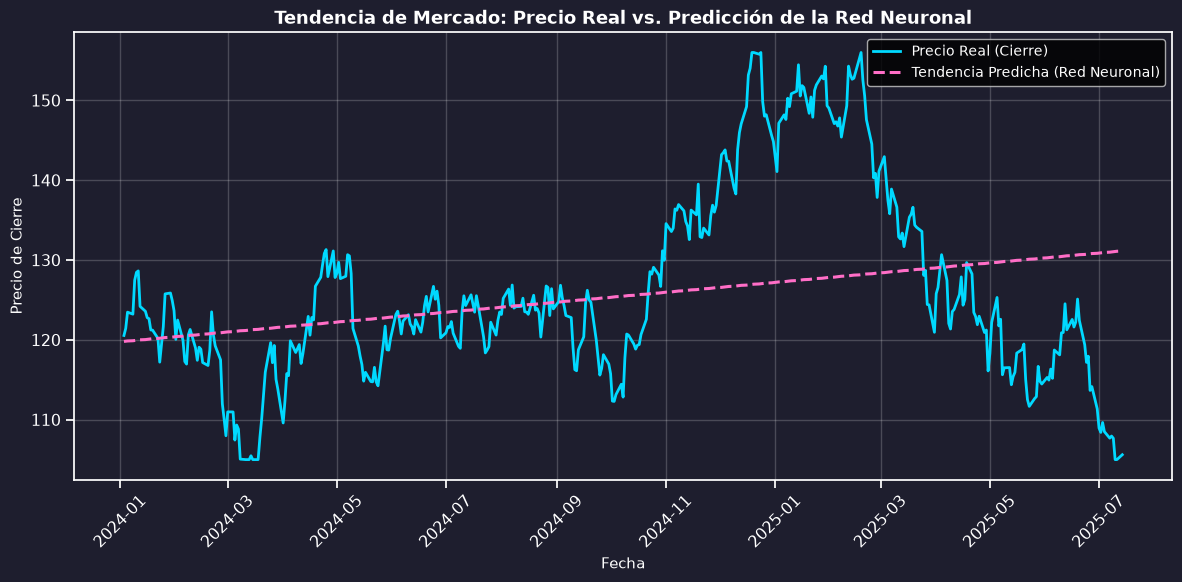

In [24]:
# LIBRERÍA: MATPLOTLIB
# Gráfico de líneas: tendencia de mercado real vs. predicha por la red neuronal

import matplotlib.pyplot as plt

plt.style.use('dark_background')

fig = plt.figure(figsize=(12, 6), facecolor='#1e1e2e')
plt.gca().set_facecolor('#1e1e2e')
plt.plot(df['Fecha'], df['Cierre'], label='Precio Real (Cierre)', color='#00d9ff', linewidth=2)
plt.plot(df['Fecha'], df['Tendencia_Predicha'], label='Tendencia Predicha (Red Neuronal)', color='#ff6ec7', linewidth=2.2, linestyle='--')
plt.title('Tendencia de Mercado: Precio Real vs. Predicción de la Red Neuronal', fontsize=13, fontweight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Precio de Cierre', fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_tendencia.png', dpi=150, facecolor='#1e1e2e')
plt.show()

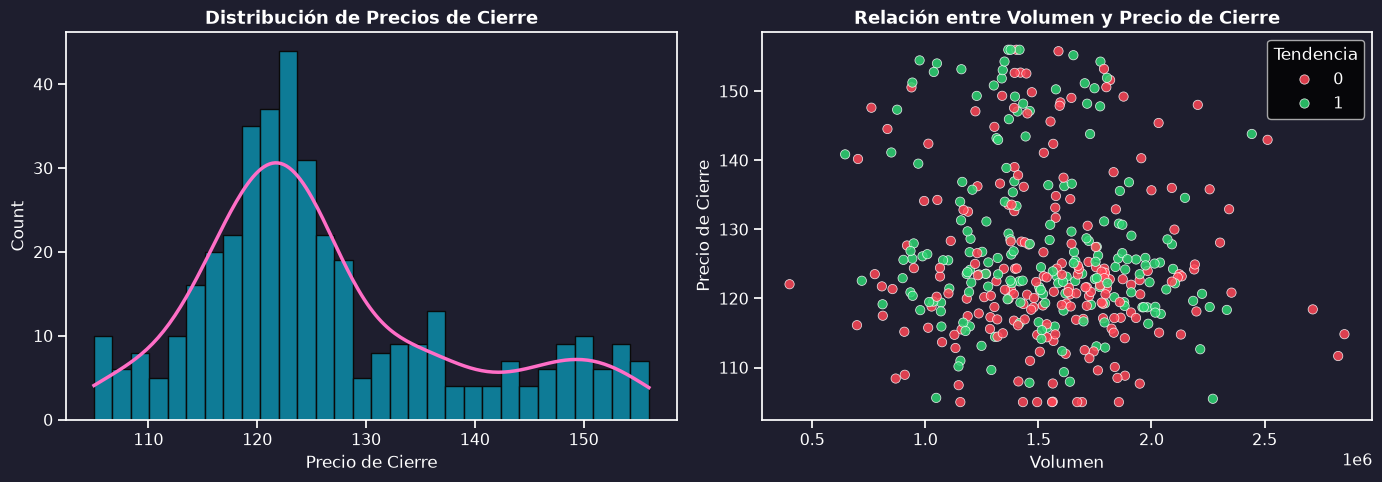

In [25]:
# LIBRERÍA: SEABORN
# Histograma de precios de cierre y dispersión Volumen vs Cierre

import seaborn as sns

plt.style.use('dark_background')
sns.set_context('notebook', font_scale=1.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#1e1e2e')

# Histograma
sns.histplot(df['Cierre'], bins=30, kde=True, color='#00d9ff', edgecolor='#0a0a0a', ax=axes[0])
axes[0].lines[0].set_color('#ff6ec7')
axes[0].lines[0].set_linewidth(2.5)
axes[0].set_title('Distribución de Precios de Cierre', fontsize=13, fontweight='bold', color='white')
axes[0].set_xlabel('Precio de Cierre')
axes[0].set_facecolor('#1e1e2e')

# Dispersión
sns.scatterplot(data=df, x='Volumen', y='Cierre', hue='Tendencia', 
                 palette={0: '#ff4757', 1: '#2ed573'}, s=45, alpha=0.85, ax=axes[1])
axes[1].set_title('Relación entre Volumen y Precio de Cierre', fontsize=13, fontweight='bold', color='white')
axes[1].set_xlabel('Volumen')
axes[1].set_ylabel('Precio de Cierre')
axes[1].set_facecolor('#1e1e2e')

plt.tight_layout()
plt.savefig('grafico_histograma_dispersion.png', dpi=150, facecolor='#1e1e2e')
plt.show()

In [26]:
# LIBRERÍA: NLTK
# Procesamiento de Lenguaje Natural sobre un reporte financiero simulado
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

reporte_financiero = """
El mercado mostró una tendencia alcista durante el último trimestre.
Los analistas destacan un crecimiento sostenido en el volumen de negociación.
Sin embargo, se observan señales de volatilidad que podrían generar una corrección a corto plazo.
Los inversionistas se muestran optimistas respecto al comportamiento futuro del activo.
"""

print('---TOKENIZACIÓN DEL REPORTE---')
tokens = word_tokenize(reporte_financiero.lower())
print(tokens)

stop_words = stopwords.words('spanish')
tokens_limpios = [t for t in tokens if t.isalpha() and t not in stop_words]

print('\n---TOKENS LIMPIOS ---')
print(tokens_limpios)

---TOKENIZACIÓN DEL REPORTE---
['el', 'mercado', 'mostró', 'una', 'tendencia', 'alcista', 'durante', 'el', 'último', 'trimestre', '.', 'los', 'analistas', 'destacan', 'un', 'crecimiento', 'sostenido', 'en', 'el', 'volumen', 'de', 'negociación', '.', 'sin', 'embargo', ',', 'se', 'observan', 'señales', 'de', 'volatilidad', 'que', 'podrían', 'generar', 'una', 'corrección', 'a', 'corto', 'plazo', '.', 'los', 'inversionistas', 'se', 'muestran', 'optimistas', 'respecto', 'al', 'comportamiento', 'futuro', 'del', 'activo', '.']

---TOKENS LIMPIOS ---
['mercado', 'mostró', 'tendencia', 'alcista', 'último', 'trimestre', 'analistas', 'destacan', 'crecimiento', 'sostenido', 'volumen', 'negociación', 'embargo', 'observan', 'señales', 'volatilidad', 'podrían', 'generar', 'corrección', 'corto', 'plazo', 'inversionistas', 'muestran', 'optimistas', 'respecto', 'comportamiento', 'futuro', 'activo']


In [27]:

# NLTK: Extracción de información relevante
# Frecuencia de palabras clave en el reporte financiero

from nltk import FreqDist

frecuencia = FreqDist(tokens_limpios)

print('---PALABRAS MÁS FRECUENTES EN EL REPORTE---')
for palabra, veces in frecuencia.most_common(10):
    print(f'{palabra}: {veces}')

---PALABRAS MÁS FRECUENTES EN EL REPORTE---
mercado: 1
mostró: 1
tendencia: 1
alcista: 1
último: 1
trimestre: 1
analistas: 1
destacan: 1
crecimiento: 1
sostenido: 1
